# Masking, tokenization, and sequence packing

CPU companion; no accelerator is required. TPU execution not validated.

- Build a causal mask from positions
- Keep token IDs and targets aligned
- Combine causal and segment boundaries
- Handle padding without an all-masked softmax

An attention head should not always see every token. For example, a next-token model must not peek at the future. We’ll build a causal mask one row at a time, then add padding and boundaries between packed examples. Before training, you’ll be able to explain exactly which positions may read each other.

## The idea

An attention mask controls which positions supply context. A loss mask controls which targets contribute to the objective. Tokenization, target shifting and sequence packing decide the positions to which those different rules apply.

## Keep context eligibility separate from scored targets

At input position $t$, causal next-token training predicts target $t+1$. A response-only role flag must follow that shifted target. Using unshifted role flags can score the wrong token at the prompt/response boundary.

An unscored prompt token can still influence a scored response through attention. Removing its direct loss does not remove it from the computation. A blocked attention edge instead prevents a context contribution.

Packed documents need segment boundaries in addition to a causal triangle. A later segment must not read an unrelated earlier segment merely because its positions occur earlier in the tensor. Trace one query and target across these rules before trusting a batch average.

### Pause and reason

Why is a triangular mask alone insufficient for packed documents?

<details><summary>Compare your reasoning</summary>

It blocks future positions but can allow one document to attend to another earlier document. Segment eligibility must enforce the intended document separation.

</details>

## Build a causal mask from positions

For query position i, allow keys j ≤ i. Including the diagonal lets a token use its own representation. The model predicts the next token from that prefix; the target array is shifted one position ahead. Excluding the diagonal is a different convention that requires changing how inputs and labels are aligned.

With values $2$, $4$, $8$, $16$ and uniform permitted scores, the outputs are prefix means: $2$, $3$, $14/3$ and $7.5$. Changing the last value must not change the first three outputs. This counterfactual tests causal isolation directly.

```text
allowed key columns
query 0: 1 0 0 0
query 1: 1 1 0 0
query 2: 1 1 1 0
query 3: 1 1 1 1
```

## Keep token IDs and targets aligned

For vocabulary {a:$0$, b:$1$, c:$2$}, abcab becomes $[0,1,2,0,1]$. Inputs $[0,1,2,0]$ pair with next-token targets $[1,2,0,1]$. Do not train the last token to predict the first token of an unrelated packed example. A separator or an ignored loss position must express that boundary.

Production tokenizers introduce normalization, special IDs and subword rules. This lesson teaches alignment using a simple character mapping and does not claim to replace them. Validate unknown characters explicitly rather than silently assigning an existing ID.

## Combine causal and segment boundaries

Packing segments $[0,0,1,1]$ means positions $2$ and $3$ belong to a new example. Require equal segment IDs as well as causal order. With our values, packed means become $2$, $3$, $8$ and $12$. Position $2$ must not read earlier positions from segment $0$ even though they are causally prior.

Segment IDs must identify separate examples within a packed row. Reusing an ID for two unrelated spans could reconnect them. The mask is only one part of packing: target eligibility must also stop at each segment boundary.

## Handle padding without an all-masked softmax

An all-masked row represented by all −infinity scores has no normalized distribution and can produce NaN. Padding queries create precisely that row if you forbid every key. Provide a harmless fallback key for those queries, then replace their outputs with zero and ignore their loss. Every real query still uses its original permitted keys.

The fallback is a numerical convention, not permission for padding to carry semantic information. Test that perturbing padded values does not change real outputs. Also reject any real query with no valid key when that violates your model contract.

## Turn the allowed positions into weights

For causal attention, query position $i$ may use key position $j$ only when $j\le i$. We leave an allowed score unchanged and replace a blocked score with negative infinity before softmax. This gives blocked positions zero weight when the row has at least one allowed key. If a row is entirely blocked, an ordinary softmax has no valid distribution; handle that case explicitly, as the code does.

$$
\widetilde S_{ij}=\begin{cases}S_{ij}&\text{if key }j\text{ is allowed for query }i\\-\infty&\text{otherwise}\end{cases}
$$

## 1. Prepare the experiment

In the CPU environment from setup, create main.py and add this block. Write down the dimensions and the known result before continuing.

In [1]:
# Step 1 — 1. Prepare the experiment: These imports provide JAX array transformations and NumPy...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

These imports provide JAX array transformations and NumPy reference calculations. Define the numerical functions next; the final build block supplies the concrete fixture and checks.

## 2. Implement the mechanism

Append this block in the same file. Follow the shape diagram above and identify each reduction or state transition.

In [2]:
# Step 2 — 2. Implement the mechanism: allowed key columns query 0: 1 0 0 0 query 1: 1 1 0 0 query 2: 1 1...
def masked_mean(values, allowed):
    # Combine or mask array elements to form `scores`.
    scores = jnp.where(allowed, 0., -jnp.inf)
    # Apply nonlinear activation or probability normalization to compute `weights`.
    weights = jax.nn.softmax(scores, axis=-1)
    # Return `(weights @ values, weights)` to the caller.
    return weights @ values, weights

# Function `make_mask(segment_ids, valid)` implementing this stage's computation:
def make_mask(segment_ids, valid):
    # Initialize array `positions` with explicit values and shape.
    positions = jnp.arange(segment_ids.shape[0])
    # Evaluate `causal` from the current inputs and state.
    causal = positions[:, None] >= positions[None, :]
    # Evaluate `same_segment` from the current inputs and state.
    same_segment = segment_ids[:, None] == segment_ids[None, :]
    # Return `causal & same_segment & valid[:, None] & valid[None, :]` to the caller.
    return causal & same_segment & valid[:, None] & valid[None, :]

allowed key columns
query $0$: $1$ $0$ $0$ $0$
query $1$: $1$ $1$ $0$ $0$
query $2$: $1$ $1$ $1$ $0$
query $3$: $1$ $1$ $1$ $1$

## 3. Run and check

Append this block and run python main.py. Compare its output with your prediction. An assertion failure means a stated contract needs investigation.

In [3]:
# Step 3 — 3. Run and check: Causal means [2, 3, 4.666667, 7.5]; no weight above the diagonal.
# Initialize array `values` with explicit values and shape.
values = jnp.array([[2.], [4.], [8.], [16.]])
# Initialize array `causal` with explicit values and shape.
causal = jnp.arange(4)[:, None] >= jnp.arange(4)[None, :]
# Run `masked_mean` to compute `(out, weights)`.
out, weights = masked_mean(values, causal)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(out[:, 0], jnp.array([2., 3., 14/3, 7.5]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.triu(weights, 1), 0.)
# Print the observed values to compare against the expected result.
print("Causal means:", out[:, 0])

Causal means: [2.       3.       4.666667 7.5     ]


Causal means $[2, 3, 4.666667, 7.5]$; no weight above the diagonal.

## Run the example

In [4]:
# Step 1 — 1. Prepare the experiment: These imports provide JAX array transformations and NumPy...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Step 2 — 2. Implement the mechanism: allowed key columns query 0: 1 0 0 0 query 1: 1 1 0 0 query 2: 1 1...
def masked_mean(values, allowed):
    # Combine or mask array elements to form `scores`.
    scores = jnp.where(allowed, 0., -jnp.inf)
    # Apply nonlinear activation or probability normalization to compute `weights`.
    weights = jax.nn.softmax(scores, axis=-1)
    # Return `(weights @ values, weights)` to the caller.
    return weights @ values, weights

# Function `make_mask(segment_ids, valid)` implementing this stage's computation:
def make_mask(segment_ids, valid):
    # Initialize array `positions` with explicit values and shape.
    positions = jnp.arange(segment_ids.shape[0])
    # Evaluate `causal` from the current inputs and state.
    causal = positions[:, None] >= positions[None, :]
    # Evaluate `same_segment` from the current inputs and state.
    same_segment = segment_ids[:, None] == segment_ids[None, :]
    # Return `causal & same_segment & valid[:, None] & valid[None, :]` to the caller.
    return causal & same_segment & valid[:, None] & valid[None, :]

# Step 3 — 3. Run and check: Causal means [2, 3, 4.666667, 7.5]; no weight above the diagonal.
# Initialize array `values` with explicit values and shape.
values = jnp.array([[2.], [4.], [8.], [16.]])
# Initialize array `causal` with explicit values and shape.
causal = jnp.arange(4)[:, None] >= jnp.arange(4)[None, :]
# Run `masked_mean` to compute `(out, weights)`.
out, weights = masked_mean(values, causal)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(out[:, 0], jnp.array([2., 3., 14/3, 7.5]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.triu(weights, 1), 0.)
# Print the observed values to compare against the expected result.
print("Causal means:", out[:, 0])

Causal means: [2.       3.       4.666667 7.5     ]


Expected: Causal means $[2, 3, 4.666667, 7.5]$; no weight above the diagonal.

## A causal mask blocks future information

Predict: Which cells must remain zero?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: A causal mask blocks future information
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'heatmap', 'values': weights.tolist(), 'rows': ['query ' + str(i) for i in range(4)], 'columns': ['key ' + str(i) for i in range(4)], 'unit': 'attention weight'}

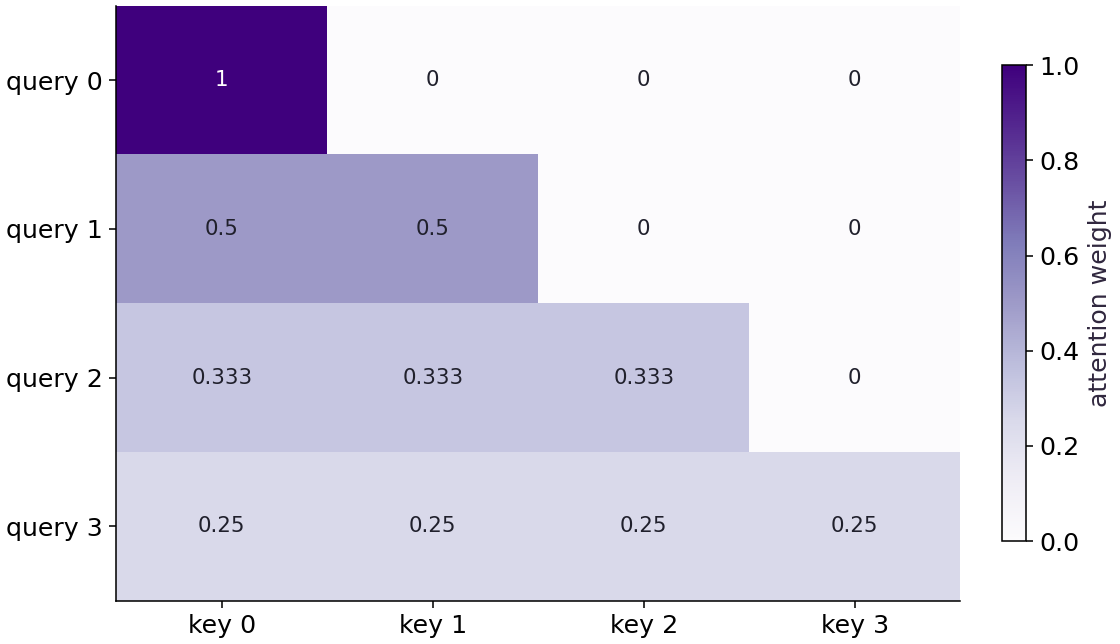

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Rows select query positions and columns select key positions. The diagonal and cells to its left are allowed; the white cells to the right of the diagonal have exactly zero attention weight because they refer to future tokens.

Query $0$ puts all its weight on key $0$. Query $1$ splits weight equally across keys $0$ and $1$. The last row assigns $1/4$ to every key because, at the last position, all four positions are available.

### Connect it to the computation

The allowed scores are equal in this constructed example, so each row averages its visible prefix. The causal mask determines which entries must be zero; it does not generally make the remaining entries uniform. Learned scores can distribute weight unevenly within the allowed region.

For values $(2,4,8,16)$, query $2$ returns $(2+4+8)/3=14/3$, not the full-sequence average $7.5$. The zero in its last column is what prevents the future value $16$ from influencing that result. Verify normalization across rows, not down columns.

## Perturb the future

Predict: If the last value becomes $1000$, which outputs may change?

In [7]:
# Experiment — Perturb the future: Perturbation tests whether earlier representations depend on...
changed = values.at[-1, 0].set(1000.)
# Run `masked_mean` to compute `(changed_out, _)`.
changed_out, _ = masked_mean(changed, causal)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(changed_out[:3], out[:3])
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.allclose(changed_out[-1], out[-1])

Expected: Only the last output changes.

Perturbation tests whether earlier representations depend on future information.

## Pack two independent examples

Predict: What are the means for segments $[0,0,1,1]$?

In [8]:
# Experiment — Pack two independent examples: Causal order alone does not isolate independent packed examples.
# Initialize array `segments` with explicit values and shape.
segments = jnp.array([0, 0, 1, 1])
# Initialize array `valid` with explicit values and shape.
valid = jnp.ones(4, dtype=bool)
# Run `make_mask` to compute `packed`.
packed = make_mask(segments, valid)
# Run `masked_mean` to compute `(packed_out, _)`.
packed_out, _ = masked_mean(values, packed)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(packed_out[:, 0], jnp.array([2., 3., 8., 12.]))

Expected: Packed means $[2, 3, 8, 12]$.

Causal order alone does not isolate independent packed examples.

## Your exercise

Encode abcab with a three-character vocabulary. Create shifted inputs/targets, and a loss-eligibility vector for packed segments $[0,0,0,1,1]$ that excludes a cross-segment next-token target.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.

**Step-by-step implementation plan:**
1. Initialize array `ids` with explicit values and shape.
2. Verify contract: `jnp.array_equal(ids[:-1], jnp.array([0, 1, 2, 0]))`.
3. Verify that the output satisfies the expected shape, finite-value, or numerical contract.
4. Initialize array `seg` with explicit values and shape.
5. Evaluate `loss_valid` from the current inputs and state.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Encode abcab with a three-character vocabulary.
vocab = ...  # TODO: compute vocab
# Initialize array `ids` with explicit values and shape.
ids = jnp.array(...)  # TODO: compute ids
# Verify contract: `jnp.array_equal(ids[:-1], jnp.array([0, 1, 2, 0]))`.
assert jnp.array_equal(ids[:-1], jnp.array([0,1,2,0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.array_equal(ids[1:], jnp.array([1,2,0,1]))  # TODO: complete assertion check
# Initialize array `seg` with explicit values and shape.
seg = jnp.array(...)  # TODO: compute seg
# Evaluate `loss_valid` from the current inputs and state.
loss_valid = ...  # TODO: compute loss_valid
# Verify contract: `jnp.array_equal(loss_valid, jnp.array([True, True, False, True]))`.
assert jnp.array_equal(loss_valid, jnp.array([True,True,False,True]))  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Encode abcab with a three-character vocabulary.
# vocab = ...  # TODO: compute vocab
# Initialize array `ids` with explicit values and shape.
# ids = jnp.array(...)  # TODO: compute ids
# Verify contract: `jnp.array_equal(ids[:-1], jnp.array([0, 1, 2, 0]))`.
# assert jnp.array_equal(ids[:-1], jnp.array([0,1,2,0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.array_equal(ids[1:], jnp.array([1,2,0,1]))  # TODO: complete assertion check
# Initialize array `seg` with explicit values and shape.
# seg = jnp.array(...)  # TODO: compute seg
# Evaluate `loss_valid` from the current inputs and state.
# loss_valid = ...  # TODO: compute loss_valid
# Verify contract: `jnp.array_equal(loss_valid, jnp.array([True, True, False, True]))`.
# assert jnp.array_equal(loss_valid, jnp.array([True,True,False,True]))  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Encode abcab with a three-character vocabulary.
vocab = {"a":0, "b":1, "c":2}
# Initialize array `ids` with explicit values and shape.
ids = jnp.array([vocab[c] for c in "abcab"])
# Verify contract: `jnp.array_equal(ids[:-1], jnp.array([0, 1, 2, 0]))`.
assert jnp.array_equal(ids[:-1], jnp.array([0,1,2,0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.array_equal(ids[1:], jnp.array([1,2,0,1]))
# Initialize array `seg` with explicit values and shape.
seg = jnp.array([0,0,0,1,1])
# Evaluate `loss_valid` from the current inputs and state.
loss_valid = seg[:-1] == seg[1:]
# Verify contract: `jnp.array_equal(loss_valid, jnp.array([True, True, False, True]))`.
assert jnp.array_equal(loss_valid, jnp.array([True,True,False,True]))

## Repair padding-query NaNs · Transfer / diagnosis

Use `valid=[True,True,False,False]`. Reproduce the undefined all-masked rows, then give padded queries a fallback and zero their outputs.

Hint: Insert a diagonal fallback only for invalid queries.

### How to write: Repair padding-query NaNs — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.zeros / jnp.ones(shape, dtype=...)` — Allocates a tensor of the given `shape` initialized with constants.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jnp.isfinite(x)` — Returns a boolean mask verifying that no element is `NaN` or `Inf`.

**Step-by-step implementation plan:**
1. Initialize array `pad_valid` with explicit values and shape.
2. Initialize array `pad_mask` with explicit values and shape.
3. Combine or mask array elements to form `(bad_pad, _)`.
4. Confirm that all computed values remain finite (no NaN or Inf).
5. Initialize array `fallback` with explicit values and shape.

**Starter code scaffold (fill in the TODOs):**

```python
# Repair padding-query NaNs (Transfer / diagnosis): A fallback makes normalization defined; zeroing and loss...
# Initialize array `pad_valid` with explicit values and shape.
pad_valid = jnp.array(...)  # TODO: compute pad_valid
# Initialize array `pad_mask` with explicit values and shape.
pad_mask = make_mask(...)  # TODO: compute pad_mask
# Combine or mask array elements to form `(bad_pad, _)`.
bad_pad, _ = masked_mean(...)  # TODO: compute bad_pad, _
# Confirm that all computed values remain finite (no NaN or Inf).
assert not jnp.all(jnp.isfinite(bad_pad))  # TODO: complete assertion check
# Initialize array `fallback` with explicit values and shape.
fallback = ...  # TODO: compute fallback
# Combine or mask array elements to form `(pad_out, _)`.
pad_out, _ = masked_mean(...)  # TODO: compute pad_out, _
# Combine or mask array elements to form `pad_out`.
pad_out = jnp.where(...)  # TODO: compute pad_out
# Confirm that all computed values remain finite (no NaN or Inf).
assert jnp.all(jnp.isfinite(pad_out))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(pad_out[:,0], jnp.array([2.,3.,0.,0.]))  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Repair padding-query NaNs (Transfer / diagnosis): A fallback makes normalization defined; zeroing and loss...
# Initialize array `pad_valid` with explicit values and shape.
# pad_valid = jnp.array(...)  # TODO: compute pad_valid
# Initialize array `pad_mask` with explicit values and shape.
# pad_mask = make_mask(...)  # TODO: compute pad_mask
# Combine or mask array elements to form `(bad_pad, _)`.
# bad_pad, _ = masked_mean(...)  # TODO: compute bad_pad, _
# Confirm that all computed values remain finite (no NaN or Inf).
# assert not jnp.all(jnp.isfinite(bad_pad))  # TODO: complete assertion check
# Initialize array `fallback` with explicit values and shape.
# fallback = ...  # TODO: compute fallback
# Combine or mask array elements to form `(pad_out, _)`.
# pad_out, _ = masked_mean(...)  # TODO: compute pad_out, _
# Combine or mask array elements to form `pad_out`.
# pad_out = jnp.where(...)  # TODO: compute pad_out
# Confirm that all computed values remain finite (no NaN or Inf).
# assert jnp.all(jnp.isfinite(pad_out))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(pad_out[:,0], jnp.array([2.,3.,0.,0.]))  # TODO: complete assertion check

## Reference reasoning

A fallback makes normalization defined; zeroing and loss masking retain the semantic padding contract.

In [12]:
# Repair padding-query NaNs (Transfer / diagnosis): A fallback makes normalization defined; zeroing and loss...
# Initialize array `pad_valid` with explicit values and shape.
pad_valid = jnp.array([True,True,False,False])
# Initialize array `pad_mask` with explicit values and shape.
pad_mask = make_mask(jnp.zeros(4, dtype=int), pad_valid)
# Combine or mask array elements to form `(bad_pad, _)`.
bad_pad, _ = masked_mean(values, pad_mask)
# Confirm that all computed values remain finite (no NaN or Inf).
assert not jnp.all(jnp.isfinite(bad_pad))
# Initialize array `fallback` with explicit values and shape.
fallback = (~pad_valid[:, None]) & jnp.eye(4, dtype=bool)
# Combine or mask array elements to form `(pad_out, _)`.
pad_out, _ = masked_mean(values, pad_mask | fallback)
# Combine or mask array elements to form `pad_out`.
pad_out = jnp.where(pad_valid[:, None], pad_out, 0.)
# Confirm that all computed values remain finite (no NaN or Inf).
assert jnp.all(jnp.isfinite(pad_out))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(pad_out[:,0], jnp.array([2.,3.,0.,0.]))

## Detect packed-example leakage · Transfer / diagnosis

Compare causal-only and segment-aware outputs at query $2$. Explain which prior values caused the difference.

Hint: Query $2$ should see only value $8$ from its own segment.

### How to write: Detect packed-example leakage — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Verify that the numerical values match the expected reference within tolerance.
2. Verify that the output satisfies the expected shape, finite-value, or numerical contract.
3. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Detect packed-example leakage (Transfer / diagnosis): The earlier values 2 and 4 belong to another example; they...
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(out[2,0], 14/3)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(packed_out[2,0], 8.)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.allclose(out[2,0], packed_out[2,0])  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Detect packed-example leakage (Transfer / diagnosis): The earlier values 2 and 4 belong to another example; they...
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(out[2,0], 14/3)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(packed_out[2,0], 8.)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert not jnp.allclose(out[2,0], packed_out[2,0])  # TODO: complete assertion check

## Reference reasoning

The earlier values $2$ and $4$ belong to another example; they must be excluded despite being past positions.

In [14]:
# Detect packed-example leakage (Transfer / diagnosis): The earlier values 2 and 4 belong to another example; they...
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(out[2,0], 14/3)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(packed_out[2,0], 8.)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.allclose(out[2,0], packed_out[2,0])

## Checkpoint

What must a packed causal mask enforce?

1. Causal order only
2. Same segment and permitted causal keys, plus explicit padding behavior
3. Equal token IDs

## Diagnose

NaN in a padded output can mean that its mask row permits no keys; count allowed keys before blaming the optimizer. Add a fallback only for invalid queries, zero their outputs, and ignore their loss. If a packed output includes another example’s values, inspect equal-segment and causal conditions separately. Recheck the hand-derived $[2,3,8,12]$ result.

## Evidence

Keep token/target alignment, the two masks, future perturbation, segment-leakage comparison and all-masked-row repair. Verify that masks and ignored loss positions enforce the same boundaries.

## Carry forward

- Perturbation tests whether earlier representations depend on future information.
- Causal order alone does not isolate independent packed examples.

## Primary references

- [JAX softmax API](https://docs.jax.dev/en/latest/_autosummary/jax.nn.softmax.html)
- [JAX attention API](https://docs.jax.dev/en/latest/_autosummary/jax.nn.dot_product_attention.html)
- [Optax cross entropy](https://optax.readthedocs.io/en/latest/api/losses.html)